In [2]:
from DataLoader import DataLoader

dataloader = DataLoader("data")
dataloader.load_paths("paths_finished.tsv") 

In [3]:
import numpy as np

dataloader_nona = dataloader.paths.dropna()
path_lengths = [len(path) for path in dataloader_nona["path"]]

print("len", len(path_lengths))

def remove_outliers(data):
    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return (data >= lower) & (data <= upper)

mask = remove_outliers(np.array(path_lengths))
filtered_dataloader = dataloader_nona[mask]
filtered_path_lengths = np.array(path_lengths)[mask]

len 28501


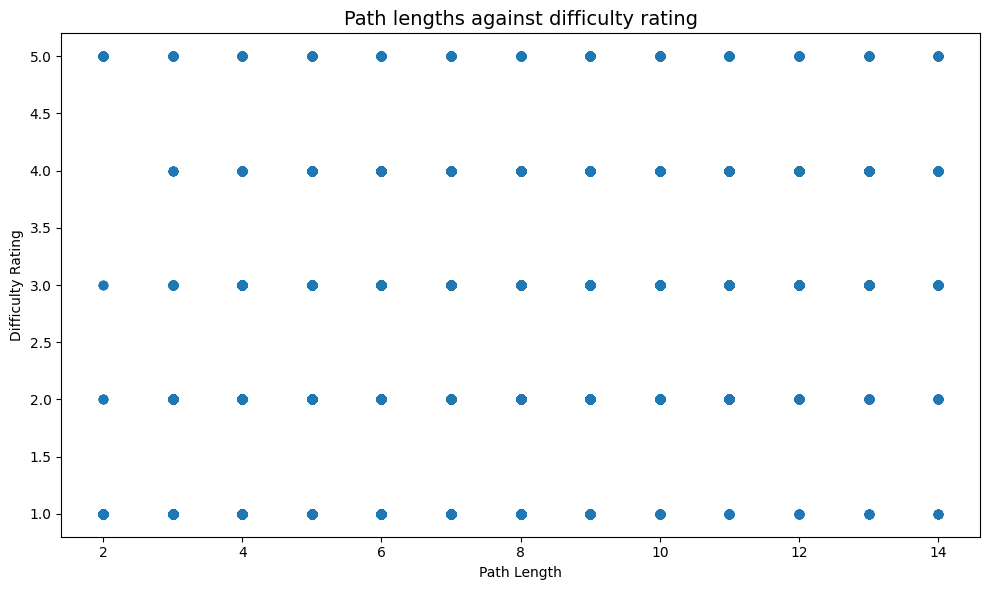

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(filtered_path_lengths, filtered_dataloader["rating"])
plt.title('Path lengths against difficulty rating', fontsize=14)
plt.xlabel('Path Length')
plt.ylabel('Difficulty Rating')
plt.tight_layout()
plt.show()

KL Divergence: 1.4214
Jensen–Shannon Divergence: 0.5723


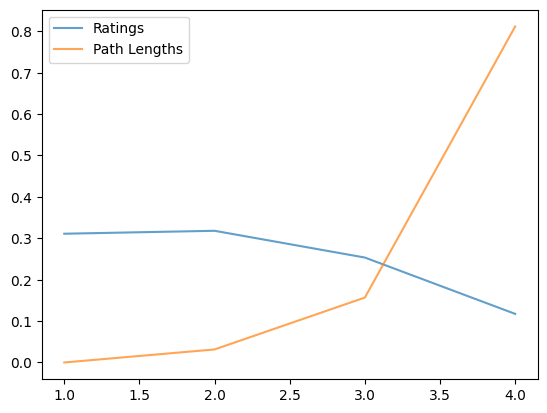

In [17]:
import numpy as np
from scipy.special import rel_entr
from scipy.spatial.distance import jensenshannon
import matplotlib.pyplot as plt

# Convert to histograms
bins = 4
p_hist, bin_edges = np.histogram(filtered_dataloader['rating'], bins=bins, density=True)
q_hist, _ = np.histogram(filtered_path_lengths, bins=bin_edges, density=True)

# Avoid zeros
eps = 1e-10
p = p_hist + eps
q = q_hist + eps
p /= p.sum()
q /= q.sum()


# Compute divergences
kl = np.sum(rel_entr(q, p))
js = jensenshannon(p, q)

print(f"KL Divergence: {kl:.4f}")
print(f"Jensen–Shannon Divergence: {js:.4f}")

plt.plot(bin_edges[:-1], p, label="Ratings", alpha=0.7)
plt.plot(bin_edges[:-1], q, label="Path Lengths", alpha=0.7)
plt.legend()
plt.show()


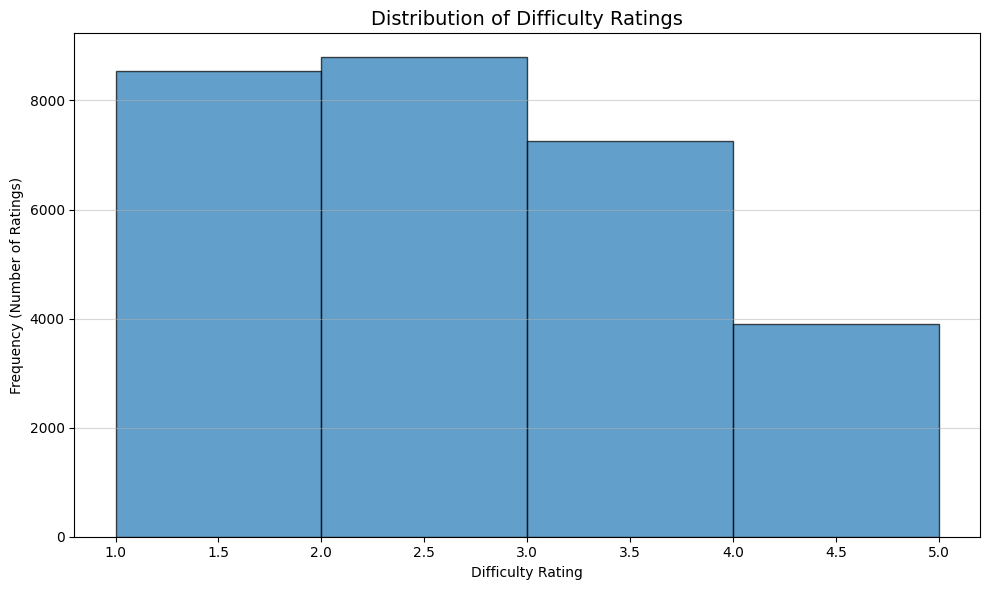

In [6]:
import matplotlib.pyplot as plt

# Filter out potential NaNs
rating_data = dataloader_nona['rating'].dropna()

plt.figure(figsize=(10, 6))
plt.hist(rating_data, bins=4, edgecolor='black', alpha=0.7)
plt.title('Distribution of Difficulty Ratings', fontsize=14)
plt.xlabel('Difficulty Rating')
plt.ylabel('Frequency (Number of Ratings)')
plt.grid(axis='y', alpha=0.5)
plt.tight_layout()
plt.show()

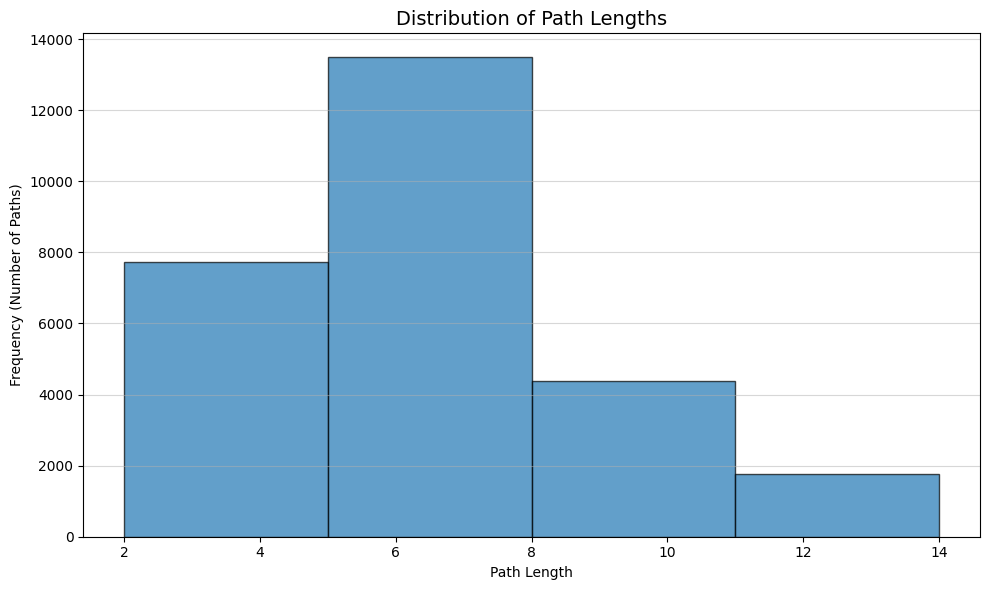

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(filtered_path_lengths, bins=4, edgecolor='black', alpha=0.7)
plt.title('Distribution of Path Lengths', fontsize=14)
plt.xlabel('Path Length')
plt.ylabel('Frequency (Number of Paths)')
plt.grid(axis='y', alpha=0.5)
plt.tight_layout()
plt.show()

Pearson correlation: 0.488 (p=0.000e+00)
Correlation between distributions: 0.225


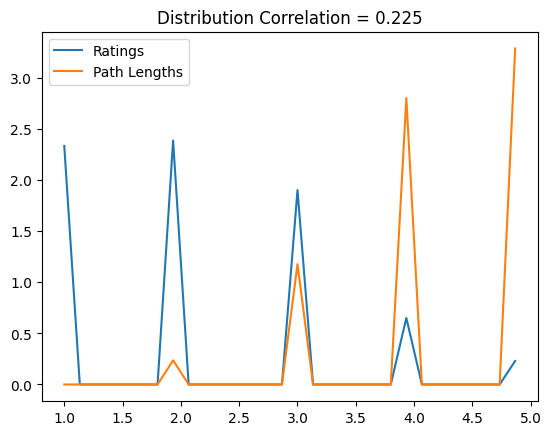

In [10]:
import numpy as np
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

corr, p_value = pearsonr(filtered_path_lengths, filtered_dataloader['rating'])
print(f"Pearson correlation: {corr:.3f} (p={p_value:.3e})")

corr, _ = pearsonr(p_hist, q_hist)
print(f"Correlation between distributions: {corr:.3f}")


plt.plot(bin_edges[:-1], p_hist, label='Ratings')
plt.plot(bin_edges[:-1], q_hist, label='Path Lengths')
plt.title(f'Distribution Correlation = {corr:.3f}')
plt.legend()
plt.show()